IMDB Dataset of 50K Movie Reviews

##Import Necessary Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [51]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##DataSet

In [52]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [26]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [27]:
#Check for empty values
missing_values = df.isnull().sum()
missing_values

,0
review,0
sentiment,0


Given the large size of the dataset, extremely short reviews were considered uninformative textual entries. Reviews containing fewer than 10 words were treated as textual missing data and removed to enhance the overall quality of the dataset without affecting class balance.

In [28]:
"""
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

df = df[df['word_count'] >= 10]

df = df.drop(columns=['word_count'])
"""

"\ndf['word_count'] = df['review'].apply(lambda x: len(x.split()))\n\ndf = df[df['word_count'] >= 10]\n\ndf = df.drop(columns=['word_count'])\n"

In [29]:
# Distribute values /in the label column
label_distribution = df['sentiment'].value_counts()
label_distribution

,count
sentiment,
positive,25000
negative,25000


<Axes: xlabel='sentiment'>

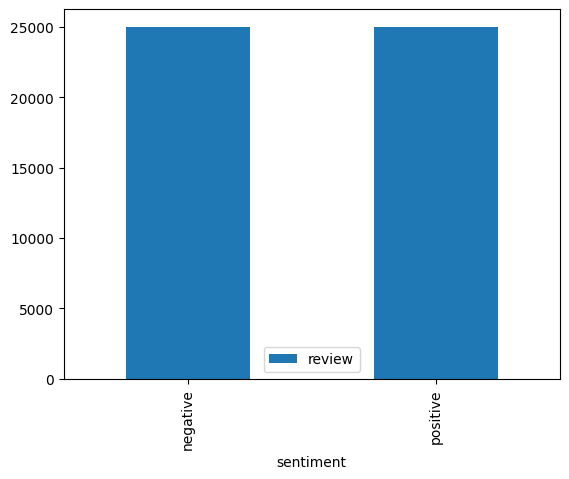

In [30]:
# The distribution of sentiments
df.groupby('sentiment').count().plot(kind='bar')

In [32]:
# Calculate the length of each review and store it in a new column 'Review_length'
df['Review_length'] = df['review'].apply(len)
# Now you can calculate the sentiment text length
sentiment_text_length = df.groupby('sentiment')['Review_length'].agg(['mean', 'median', 'std'])
sentiment_text_length

,mean,median,std
sentiment,,,
negative,1294.06436,973.0,945.892669
positive,1324.79768,968.0,1031.492627


Analysis of review length revealed very similar distributions for positive and negative sentiments. While positive reviews were slightly longer on average, the median values were nearly identical, indicating comparable review lengths across both classes. The large standard deviations reflect natural variability in user-generated reviews.

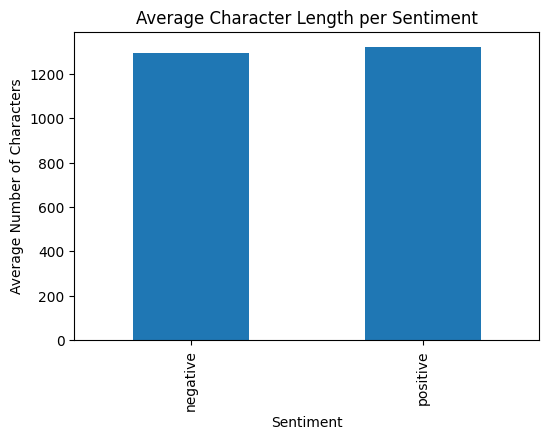

In [34]:

# Counting the number of characters
df['char_length'] = df['review'].str.len()

#Calculate the average number of characters per sentiment
avg_chars = df.groupby('sentiment')['char_length'].mean()

# drawing the diagram
plt.figure(figsize=(6,4))
avg_chars.plot(kind='bar')

plt.title("Average Character Length per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Characters")

plt.show()


In [36]:

#Word-level text length
# Calculate sentence length (number of words) for each review
df['sentence_length'] = df['review'].apply(lambda x: len(x.split()))

# Calculating the average for each sentiment
avg_sentence_length = df.groupby('sentiment')['sentence_length'].mean()
#####
print(avg_sentence_length)


sentiment
negative    229.46456
positive    232.84932
Name: sentence_length, dtype: float64


The average number of words per review was calculated for each sentiment class. The results show only minor differences between positive and negative reviews, indicating that review length alone is not a strong indicator of sentiment.

##preprosing

In [37]:
# ----------  Encode Labels ----------
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})


In [53]:
lemmatizer = WordNetLemmatizer()

# Stopwords while preserving the negation
stop_words = set(stopwords.words('english'))
stop_words -= {'not', 'no', 'never'}

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs, mentions, hashtags
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)

    # Remove punctuation & numbers
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords (except negation)
    words = [w for w in text.split() if w not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['Cleaned_Review'] = df['review'].apply(clean_text)


Text preprocessing was performed by removing HTML tags, punctuation, and stopwords. All text was converted to lowercase, and lemmatization was applied to normalize word forms.

###featuar eng

In [39]:
X = df['Cleaned_Review']
y = df['sentiment']


Build Pipeline

In [40]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        max_features=15000,
        min_df=5,
        max_df=0.85
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear'
    ))
])


Cross Validation Evaluati

In [41]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

In [42]:
print("===== Cross Validation Results (Mean) =====")
print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1-score : {cv_results['test_f1'].mean():.4f}")

===== Cross Validation Results (Mean) =====
Accuracy : 0.8977
Precision: 0.8904
Recall   : 0.9070
F1-score : 0.8986


Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV to optimize the regularization parameter (C) of the Logistic Regression model.

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:


param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.85,
                                                        max_features=15000,
                                                        min_df=5,
                                                        ngram_range=(1, 2))),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 2, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1')

In [45]:
print("\n===== Best Hyperparameters =====")
print(grid.best_params_)
print(f"Best CV F1-score: {grid.best_score_:.4f}")



===== Best Hyperparameters =====
{'clf__C': 5, 'tfidf__ngram_range': (1, 2)}
Best CV F1-score: 0.9013


Train Final Model

In [46]:
best_model = grid.best_estimator_
best_model.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.85, max_features=15000, min_df=5,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(C=5, class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

Save Final Model

In [47]:
import joblib

joblib.dump(best_model, "best_logistic_sentiment_model.pkl")
print("\nModel saved successfully!")


Model saved successfully!
